# Task 2B - 01 Data audit
Scenario S1: one dispatch day at Peliyagoda, orders closed, a festival a week away, several vehicles in the workshop. We must mark every order served/deferred and give every served order a vehicle and trip.

**Questions for this notebook:** are the inputs clean, what is actually available (workshop vehicles excluded), and how does demand compare with capacity?

In [1]:
import sys, warnings; warnings.filterwarnings('ignore')
sys.path.append('../../tools/task2b')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json, time
from task2b_common import *
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 50); pd.set_option('display.max_rows', 120)
plt.rcParams.update({'figure.dpi': 90, 'axes.grid': True, 'grid.alpha': .25})
for d in (METRICS, FIGURES, INTERIM): d.mkdir(parents=True, exist_ok=True)
scn, fleet, veh, dt, al = load_tables()
sub_team = pd.read_csv(SUBMISSION)            # the teammate's submitted allocation (read-only)


## 1. Orders

In [2]:
print('orders:', scn.shape, '| unique order_ref:', scn.order_ref.is_unique, '| scenarios:', scn.scenario.unique(), '| depots:', scn.depot.unique())
print('outlets with more than one order:', int((scn.outlet_id.value_counts() > 1).sum()), '(so order_ref, not outlet_id, is the allocation key)')
print('missing values per column:'); print(scn.isna().sum()[lambda s: s > 0])
print()
print(scn.groupby(['brand', 'temp_requirement']).agg(orders=('order_ref', 'size'), m3=('order_volume_m3', 'sum'), kg=('order_weight_kg', 'sum')).round(1))
print('\nparking constraints:', scn.parking_constraint.value_counts().to_dict(), '| dock types:', scn.dock_type.value_counts().to_dict())

orders: (85, 17) | unique order_ref: True | scenarios: <StringArray>
['S1']
Length: 1, dtype: str | depots: <StringArray>
['Peliyagoda']
Length: 1, dtype: str
outlets with more than one order: 26 (so order_ref, not outlet_id, is the allocation key)
missing values per column:
mall_window    83
dtype: int64

                        orders     m3       kg
brand temp_requirement                        
Fresh ambient               49  133.0  24838.4
      chilled               26  181.6  32780.4
Style ambient                5   77.2   4878.3
Tech  ambient                5   18.1   5642.3

parking constraints: {'normal': 77, 'van_only': 6, 'mall_dock': 2} | dock types: {'rear_dock': 56, 'street': 27, 'mall_bay': 2}


`mall_window` is empty for non-mall outlets; the two `mall_dock` orders (one Tech, one Style) can only be delivered inside their 10:00-12:00 mall window. `van_only` outlets (6 orders: three outlets x one ambient + one chilled order) cannot be served by trucks.

## 2. Fleet: what is really available

In [3]:
f = fleet.merge(veh, on='vehicle_id')
print('fleet file rows:', len(fleet), '| status:', fleet.status.value_counts().to_dict(), '| depots:', f.depot.unique())
f['class'] = f.type + '/' + f.temp
print(f.groupby(['status', 'class']).agg(vehicles=('vehicle_id', 'size'), m3_each=('volume_cap_m3', 'mean'), kg_each=('weight_cap_kg', 'mean')).round(1))
print('\nin workshop:', f[f.status == 'in_workshop'].vehicle_id.tolist())
print('reefers in workshop:', f[(f.status == 'in_workshop') & (f.temp == 'reefer')].vehicle_id.tolist())

fleet file rows: 38 | status: {'available': 28, 'in_workshop': 10} | depots: <StringArray>
['Peliyagoda']
Length: 1, dtype: str
                           vehicles  m3_each  kg_each
status      class                                    
available   truck/ambient        22     29.8   5527.3
            truck/reefer          3     26.4   5320.0
            van/ambient           2      8.5   1150.0
            van/reefer            1      7.0   1040.0
in_workshop truck/ambient         5     26.4   4720.0
            truck/reefer          4     28.6   5795.0
            van/reefer            1      7.0   1040.0

in workshop: ['VEH001', 'VEH002', 'VEH004', 'VEH005', 'VEH012', 'VEH016', 'VEH021', 'VEH022', 'VEH026', 'VEH035']
reefers in workshop: ['VEH001', 'VEH002', 'VEH004', 'VEH005', 'VEH035']


**Finding.** Only 28 of the 38 listed vehicles may be used. The workshop holds **5 of the fleet's reefers** (the chilled-capable vehicles), leaving 3 reefer trucks and 1 reefer van. Reefer capacity - not total fleet size - is what will limit service on a day with rising dairy/meat/produce demand.

## 3. Demand by district and travel time

            orders  chilled_orders     m3  chilled_m3  outbound_min  inter_stop_min
district                                                                           
Colombo         26               9  101.9        51.6            24               8
Gampaha         16               6   80.6        48.1            37               9
Kalutara        10               3   33.9        16.0            64              12
Galle           10               2   55.2        20.3           103               9
Kurunegala      11               3   90.4        25.0           127              19
Matara           8               2   32.4        12.0           137              10
Puttalam         4               1   15.5         8.7           173              24


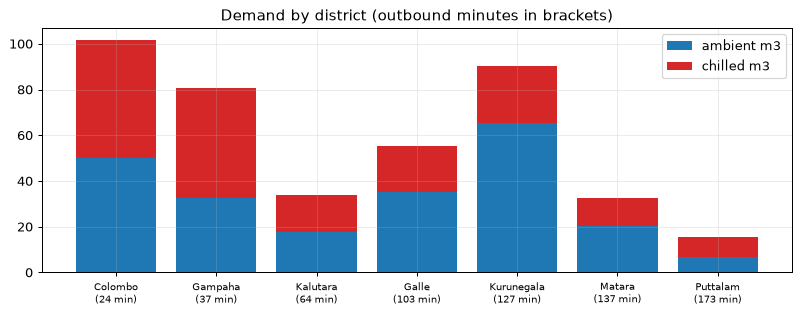

In [4]:
d = dt.set_index('district')
t = scn.assign(chilled_m3=np.where(scn.temp_requirement == 'chilled', scn.order_volume_m3, 0)).groupby('district').agg(
    orders=('order_ref', 'size'), chilled_orders=('temp_requirement', lambda s: int((s == 'chilled').sum())), m3=('order_volume_m3', 'sum'), chilled_m3=('chilled_m3', 'sum'))
t = t.join(d[['depot_to_district_freeflow_min', 'inter_stop_freeflow_min']].rename(columns={'depot_to_district_freeflow_min': 'outbound_min', 'inter_stop_freeflow_min': 'inter_stop_min'})).sort_values('outbound_min')
print(t.round(1))
fig, ax = plt.subplots(figsize=(9, 3.6)); x = np.arange(len(t))
ax.bar(x, t.m3 - t.chilled_m3, label='ambient m3'); ax.bar(x, t.chilled_m3, bottom=t.m3 - t.chilled_m3, label='chilled m3', color='C3')
ax.set_xticks(x); ax.set_xticklabels([f'{i}\n({int(o)} min)' for i, o in zip(t.index, t.outbound_min)], fontsize=8); ax.legend(); ax.set_title('Demand by district (outbound minutes in brackets)')
plt.tight_layout(); plt.savefig(FIGURES / '01_demand_by_district.png'); plt.show()

**Finding.** The far districts (Galle, Matara, Kurunegala, Puttalam: 103-173 outbound minutes) carry chilled demand too, and a Fresh vehicle has only 270 minutes before stores open - that makes time, not only volume, a constraint.

## 4. Demand vs capacity per resource

In [5]:
avail = fleet[fleet.status == 'available'].merge(veh, on='vehicle_id')
cap = avail.groupby('temp').agg(vehicles=('vehicle_id', 'size'), m3_per_wave=('volume_cap_m3', 'sum'), kg_per_wave=('weight_cap_kg', 'sum'))
dem = scn.groupby(scn.temp_requirement.map({'chilled': 'reefer', 'ambient': 'ambient'})).agg(orders=('order_ref', 'size'), m3=('order_volume_m3', 'sum'), kg=('order_weight_kg', 'sum'))
cmp_ = cap.join(dem); cmp_['m3_two_waves'] = cmp_.m3_per_wave * 2
cmp_['demand/capacity (2 waves)'] = (cmp_.m3 / cmp_.m3_two_waves).round(2)
print(cmp_.round(1))
cmp_.to_csv(INTERIM / 'exact_demand_vs_capacity.csv'); cmp_

         vehicles  m3_per_wave  kg_per_wave  orders     m3       kg  m3_two_waves  demand/capacity (2 waves)
temp                                                                                                        
ambient        24        673.0       123900      59  228.2  35359.0        1346.0                        0.2
reefer          4         86.2        17000      26  181.6  32780.4         172.4                        1.0


,vehicles,m3_per_wave,kg_per_wave,orders,m3,kg,m3_two_waves,demand/capacity (2 waves)
temp,,,,,,,,
ambient,24,673.0,123900,59,228.235,35359.0,1346.0,0.17
reefer,4,86.2,17000,26,181.629,32780.4,172.4,1.05


## Audit conclusions
1. Inputs are clean: unique `order_ref`, one scenario, one depot, no missing values; vehicles in the fleet file all belong to Peliyagoda.
2. 10 vehicles are in the workshop and must never be used; 5 of them are reefers.
3. Chilled demand (181.6 m3) is **more than twice** what the 4 available reefers can carry in one wave (86.2 m3) and about equal to two full waves (172.4 m3) - before the 270-minute pre-dawn limit is even considered. Ambient demand is far below ambient capacity.
4. So the day is a **reefer-capacity day**: which chilled orders to serve is the real decision; everything else should simply be served.